In [1]:
from __future__ import annotations

import yaml
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

idx = pd.IndexSlice

In [92]:
with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

# inplace update: give these gas-ish techs a more diverse palette (not all brown)
tech_colors.update({
    "SMR CC":                        "#1f77b4",  # blue
    "heat100-200 industry gas":      "#ff7f0e",  # orange
    "heat<100 industry gas":         "#2ca02c",  # green
    "Combined-Cycle Gas":            "#d62728",  # red
    "Open-Cycle Gas":                "#9467bd",  # purple
    "heat200-500 industry gas":      "#17becf",  # cyan
    "H2 electrolysis":               "#e377c2",  # pink
    "urban central gas boiler":      "#7f7f7f",  # grey
    "urban central gas CHP":         "#bcbd22",  # olive
    "rural gas boiler":              "#8c564b",  # brown (keep one brown, but not all)
    "urban decentral gas boiler":    "#aec7e8",  # light blue
    "urban decentral biomass boiler":"#92648c",  # purple
    "rural biomass boiler":          "#94312c",  # purple
    "heat>500 industry gas":         "#98df8a",  # light green
    "gas DRI":                       "#000000",  # black

    # Additions reflecting explicit categories from the picture/code:
    # (assigning suitable colors, some re-using for semantic consistency)
    ">500C industry heat and feedstock": "#17becf",   # tan/grayish
    "<500C industry heat":               "#98df8a",   # brown (matches rural gas boiler)
    "biomethane":                        "gold",   # teal
    "hydrogen heating":               "magenta",   # pink (matches SMR)
    "building heat":                  "#94312c",   # grey (matches urban central gas boiler)
    "electricity":                  "#d62728",   # red (matches Combined-Cycle Gas)
})
tech_colors['residential gas boiler'] = tech_colors['urban decentral gas boiler']
tech_colors['gas turbine'] = tech_colors['Open-Cycle Gas']
tech_colors['wind'] = tech_colors['Onshore Wind']
tech_colors['solar'] = tech_colors['solar-hsat']
tech_colors['biomass buildings'] = tech_colors['urban decentral biomass boiler']
tech_colors['biomass industry'] = tech_colors['heat200-500 industry solid biomass']
tech_colors['building heat pump'] = tech_colors['air heat pump']
tech_colors['industrial heat pump'] = tech_colors['heat<100 industry industrial heat pump medium temperature']


In [68]:
nb = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_3_latest' / 'nodal_energy_balance.csv', index_col=list(range(4)), header=list(range(5))
).loc[:,idx[:,:,:,'free']]
nb.columns = nb.columns.get_level_values(-1).astype(int)

In [69]:
bal = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_3_latest' / 'energy_balance.csv', index_col=list(range(3)), header=list(range(5))
).loc[:, idx[:,:,:,'free']]
bal.columns = bal.columns.get_level_values(-1).astype(int)

In [70]:
mp = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_3_latest' / 'prices.csv', index_col=list(range(1)), header=list(range(5))
).loc[:, idx[:,:,:,'free']]
mp.columns = mp.columns.get_level_values(-1).astype(int)

gas_price = mp.loc['gas']
gas_price.index = gas_price.index.get_level_values(-1)

In [71]:
idx = pd.IndexSlice
gas = bal.loc[idx[:, :, 'gas']]

gascon = gas.loc[gas.sum(axis=1) < 0].abs().mul(1e-6)
gascon.index = gascon.index.droplevel(0)
gascon = gascon.sort_values(gascon.columns[-1])

gasgen = gas.loc[gas.sum(axis=1) > 0].mul(1e-6)
gasgen.index = gasgen.index.droplevel(0)

In [72]:
ref = gascon.iloc[:,-1]
dis = gascon.iloc[:,:-1]

threshold_share = 0.5
gasuse_baseline = mp.columns[-1] # TWh

displaced = dis.sub(ref, axis=0).abs()

df = pd.DataFrame(index=displaced.index, columns=['phase_out_prices', 'phase_out_volume'])

for carrier in displaced.index:

    ss = displaced.loc[carrier]
    ss = ss[ss > threshold_share * ss.max()]

    if not len(ss):
        continue

    df.loc[carrier, 'phase_out_prices'] = mp.loc['gas', ss.index[-1]]
    df.loc[carrier, 'phase_out_volume'] = gasuse_baseline - ss.index[-1]

df.sort_values(by='phase_out_prices', ascending=True, inplace=True)
df.dropna(inplace=True)

ignored = [
    'gas for industry CC',
    'gas for industry',
    ]

df.drop(ignored, inplace=True)

df['gas_consumption'] = gasuse_baseline - df['phase_out_volume']
xlim_lower = 1000
xlim_upper = 4000

##### energy balances

In [140]:
eb = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_168_latest' / 'energy_balance.csv', header=list(range(5)), index_col=[0,1,2]
)
eb.columns = eb.columns.get_level_values(-1).astype(int)
prices = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_168_latest' / 'prices.csv', header=list(range(5)), index_col=[0]
)
prices.columns = prices.columns.get_level_values(-1).astype(int)

In [141]:
gas_techs_by_bus = {
    "heat<100 industry": ["heat<100 industry gas"],
    "heat100-200 industry": ["heat100-200 industry gas"],
    "heat200-500 industry": ["heat200-500 industry gas"],
    "AC": ["Combined-Cycle Gas", "Open-Cycle Gas", "urban central gas CHP"],
    "rural heat": ["rural gas boiler"],
    "urban central heat": ["urban central gas CHP", "urban central gas boiler"],
    "urban decentral heat": ["urban decentral gas boiler"],
    "Hydrogen Storage": ["SMR"],
    "heat>500 industry": ["heat>500 industry gas"],
}

nice_names = {
    "heat<100 industry": "Industry Heat <100°C",
    "heat100-200 industry": "Industry Heat 100-200°C",
    "heat200-500 industry": "Industry Heat 200-500°C",
    "AC": "Electricity",
    "rural heat": "Rural Heating",
    "urban central heat": "District Heating",
    "urban decentral heat": "Urban Decentral Heating",
    "Hydrogen Storage": "Hydrogen",
    "heat>500 industry": "Industry Heat >500°C",
}

In [142]:
costs = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_3_latest' / 'costs.csv', index_col=list(range(3)), header=list(range(5))
).sum().mul(1e-9)
costs.index = costs.index.get_level_values(-1)
# Interpolate value for 1750 instead of dropping it
if '1750' in costs.index:
    i = costs.index.get_loc('1750')
    if i > 0 and i < len(costs) - 1:
        prev_val = costs.iloc[i - 1]
        next_val = costs.iloc[i + 1]
        costs.iloc[i] = (prev_val + next_val) / 2
costs.name = 'System Cost [B€]'
costs.index.name = 'Gas Consumption [TWh/a]'

In [143]:
items = [
    # "heat>500 industry gas CC",
    "gas for industry",
    "heat>500 industry gas",
    "heat200-500 industry gas",
    # "gas for industry CC",
    # "Open-Cycle Gas",
    # "Combined-Cycle Gas",
    "gas turbine",
    "residential gas boiler",
    "urban central gas CHP",
    # "SMR CC",
    "SMR",
    "heat<100 industry gas",
    "heat100-200 industry gas",
    "biogas to gas",
]

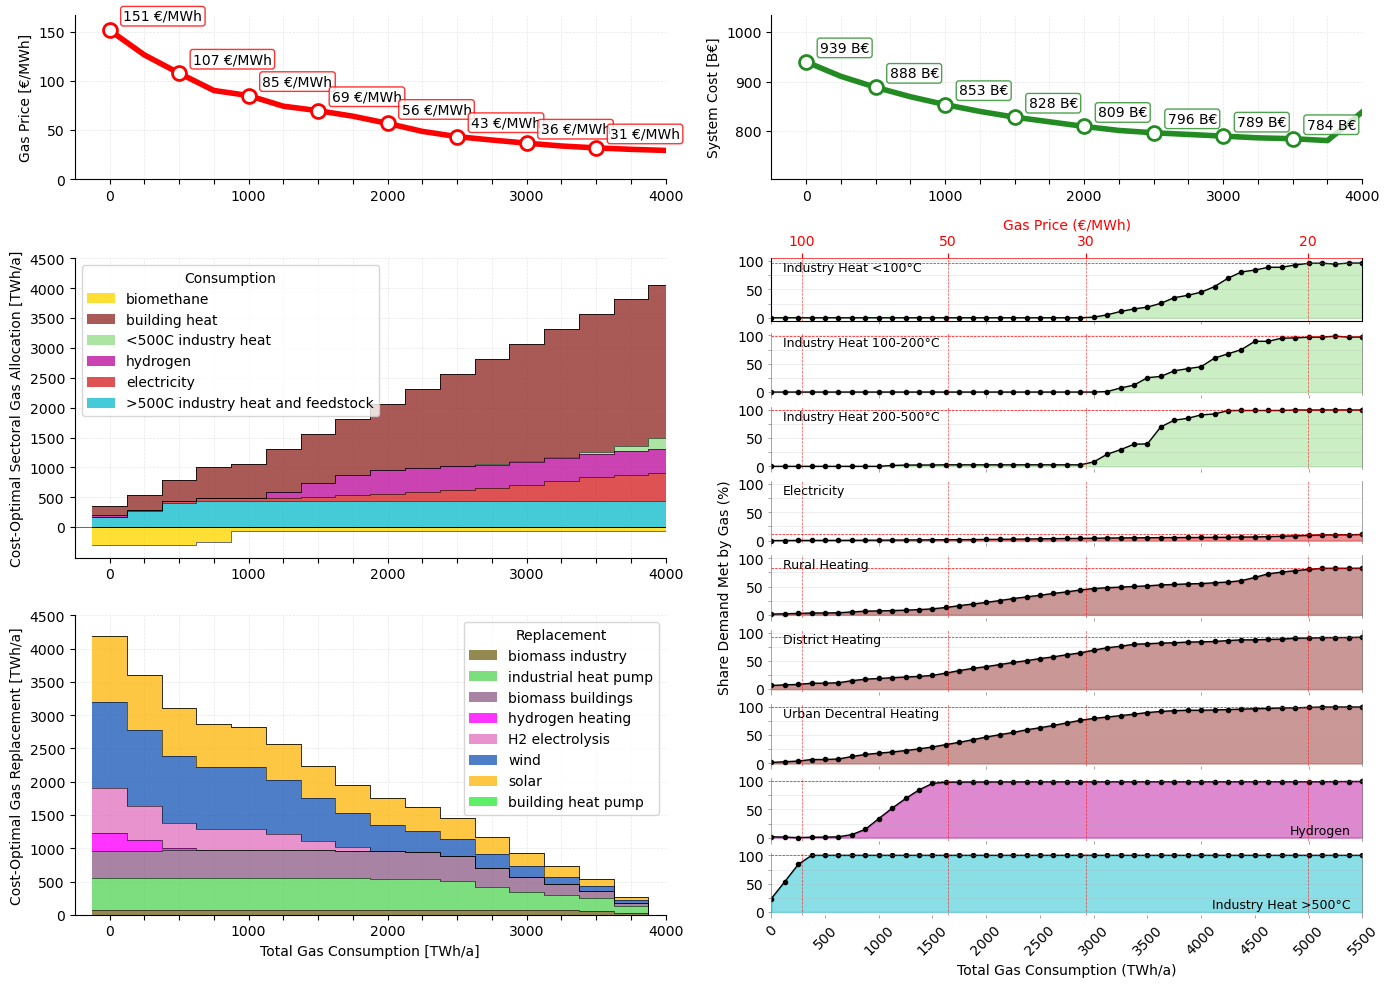

In [159]:
gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

carrier_mapping = {
    'gas for industry': '>500C industry heat and feedstock',
    'heat>500 industry gas': '>500C industry heat and feedstock',
    'heat200-500 industry gas': '<500C industry heat',
    'heat100-200 industry gas': '<500C industry heat',
    'heat<100 industry gas': '<500C industry heat',
    'biogas to gas': 'biomethane',
    'SMR': 'hydrogen',
    'urban decentral gas boiler': 'building heat',
    'urban central gas boiler': 'building heat',
    'urban central gas CHP': 'building heat',
    'rural gas boiler': 'building heat',
    'Open-Cycle Gas': 'electricity',
    'Combined-Cycle Gas': 'electricity',
}
color_mapper = {
    'heat<100 industry': '<500C industry heat',
    'heat100-200 industry': '<500C industry heat',
    'heat200-500 industry': '<500C industry heat',
    'heat>500 industry': '>500C industry heat and feedstock',
    'AC': 'electricity',
    'rural heat': 'building heat',
    'urban central heat': 'building heat',
    'urban decentral heat': 'building heat',
    'Hydrogen Storage': 'hydrogen',
}

items = [
    '>500C industry heat and feedstock',
    'electricity',
    'hydrogen',
    '<500C industry heat',
    'building heat',
    'biomethane',
]

gb = gb.groupby(carrier_mapping).sum()

line_kwargs = {
    'color': 'k',
    'linewidth': 0.5,
    'alpha': 0.8
}

fig = plt.figure(figsize=(14, 10))
outer = fig.add_gridspec(2, 2, height_ratios=[1, 4], width_ratios=[1, 1])

# Top row: two small axes
ax_top_left  = fig.add_subplot(outer[0, 0])
ax_top_right = fig.add_subplot(outer[0, 1])

# Bottom-left: split into 2 equal axes
gs_left = outer[1, 0].subgridspec(2, 1)
ax_old_0 = fig.add_subplot(gs_left[0])
ax_old_1 = fig.add_subplot(gs_left[1])

# Bottom-right: split into 7 equal axes
gs_right = outer[1, 1].subgridspec(9, 1)
ax_right = [fig.add_subplot(gs_right[i]) for i in range(9)]

ax_old_0.axhline(0, **line_kwargs)

bottoms = pd.Series(0, index=gb.columns, dtype=float)
ceilings = pd.Series(0, index=gb.columns, dtype=float)
width = 1

for i, carrier in enumerate(items):
    row = gb.loc[carrier]
    for j, con in enumerate(row.index):
        value = row.loc[con] * (-1)

        if value < 0:
            ax_old_0.bar(
                j + width/2,
                value,
                bottom=ceilings.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )
            ceilings.loc[con] += value
        else:
            ax_old_0.bar(
                j + width/2,
                value,
                bottom=bottoms.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )
            bottoms.loc[con] += value

    ax_old_0.step(
        np.arange(len(bottoms) + 1),
        np.append(bottoms.values, bottoms.values[-1]),
        where='post',
        **line_kwargs
    )
    ax_old_0.step(
        np.arange(len(bottoms) + 1),
        np.append(ceilings.values, ceilings.values[-1]),
        where='post',
        **line_kwargs
    )

ax_old_0.set_xlim(-width/2, len(bottoms) - width/2)
ax_old_0.spines['right'].set_visible(False)
ax_old_0.spines['top'].set_visible(False)
ax_old_0.grid(linestyle='--', alpha=0.3, linewidth=0.5)
ax_old_0.set_axisbelow(True)

ax_old_0.set_xticks(np.arange(len(bottoms)) + width/2)
ax_old_0.set_xticklabels(
    [label if i % 4 == 0 else '' for i, label in enumerate(bottoms.index)],
    rotation=0
)

# Add legend on the right side
handles = []
labels = []
for carrier in items[::-1]:
    if carrier == 'biogas to gas':
        continue
    if carrier in tech_colors:
        handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors[carrier], alpha=0.8))
        labels.append(carrier)

from matplotlib.lines import Line2D

ax_old_0.legend(handles, labels, loc='upper left', frameon=True, ncol=1, title='Consumption')

ax_old_0.set_xlabel('')
ax_old_0.set_ylabel('Cost-Optimal Sectoral Gas Allocation [TWh/a]')
ax_old_0.spines['top'].set_visible(False)

# Plot gas price on ax_top_left
y1_min, y1_max = ax_top_left.get_ylim()
if y1_min < 0 < y1_max:
    zero_fraction = -y1_min / (y1_max - y1_min)
else:
    zero_fraction = 0  # If y=0 is not in range, default to bottom

gas_price_min = gas_price.min()
gas_price_max = gas_price.max()
y2_max = gas_price_max * 1.1

if zero_fraction < 1:
    y2_min = -zero_fraction * y2_max / (1 - zero_fraction)
else:
    y2_min = gas_price_min * 0.9

x_gas = np.arange(len(gas_price)) + width/2
x_cost = np.arange(len(costs)) + width/2

ax_top_left.plot(
    x_gas,
    gas_price.values,
    color='red',
    linewidth=4,
    zorder=10
)
ax_top_left.set_xlim(0, len(bottoms))
ax_top_left.set_ylim(y2_min, y2_max)
ax_top_left.set_ylabel('Gas Price [€/MWh]', color='k')
ax_top_left.tick_params(axis='y', labelcolor='k')

for i in range(0, len(x_gas) - 2, 2):
    xy = (x_gas[i], gas_price.values[i])
    ax_top_left.annotate(
        f"{int(gas_price.values[i])} €/MWh",
        xy=xy,
        xytext=(10, 5),
        textcoords="offset points",
        ha='left', va='bottom',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red", lw=1, alpha=0.8),
        zorder=20
    )
    ax_top_left.plot(
        x_gas[i],
        gas_price.values[i],
        marker='o',
        color='red',
        markersize=10,
        markerfacecolor='white',
        markeredgecolor='red',
        markeredgewidth=2,
        zorder=15
    )

cost_color = 'forestgreen'
ax_top_right.plot(
    x_cost,
    costs.values,
    color=cost_color,
    linewidth=4,
    zorder=10
)
ax_top_right.set_xlim(0, len(bottoms))
costs_min = costs.min()
costs_max = costs.max()
y3_max = costs_max * 1.1
y3_min = costs_min * 0.9
ax_top_right.set_ylim(y3_min, y3_max)
ax_top_right.set_ylabel('System Cost [B€]', color='k')
ax_top_right.tick_params(axis='y', labelcolor='k')

for i in range(0, len(x_cost) - 2, 2):
    xy = (x_cost[i], costs.values[i])
    ax_top_right.annotate(
        f"{int(costs.values[i])} B€",
        xy=xy,
        xytext=(10, 5),
        textcoords="offset points",
        ha='left', va='bottom',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=cost_color, lw=1, alpha=0.8),
        zorder=20
    )
    ax_top_right.plot(
        x_cost[i],
        costs.values[i],
        marker='o',
        color=cost_color,
        markersize=10,
        markerfacecolor='white',
        markeredgecolor=cost_color,
        markeredgewidth=2,
        zorder=15
    )

for ax in [ax_top_left, ax_top_right]:
    ax.set_xlim(ax_old_0.get_xlim())
    ax.set_xticks(ax_old_0.get_xticks())
    ax.set_xticklabels(ax_old_0.get_xticklabels())
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.3, linewidth=0.5)

target_bus_carriers = {
    "Hydrogen Storage": ["SMR"],
    "AC": ["Combined-Cycle Gas", "Open-Cycle Gas"],
    "gas": ["Sabatier"],
    "biogas": ["biogas to gas"],
    "gas for industry": ["gas for industry", "gas for industry CC"],
    "heat100-200 industry": ["heat100-200 industry gas"],
    "heat200-500 industry": ["heat200-500 industry gas"],
    "heat<100 industry": ["heat<100 industry gas"],
    "heat>500 industry": ["heat>500 industry gas"],
    "rural heat": ["rural gas boiler"],
    "urban central heat": ["urban central gas CHP", "urban central gas boiler"],
    "urban decentral heat": ["urban decentral gas boiler"],
}

gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

threshold = 10 # TWh

displacers = []

for bus_carrier, gas_carriers in target_bus_carriers.items():

    ss = bal.loc[idx[:,:,bus_carrier]] / 1e6
    ss.index = ss.index.droplevel(0)

    maxgas_col = ss.loc[gas_carriers].sum().idxmax()

    diff = ss.sub(ss.loc[:,maxgas_col], axis=0).drop(gas_carriers)
    diff = diff.loc[diff.sum(axis=1) > threshold]

    displacers.append(diff)

df = pd.concat(displacers)
df = df.drop(df.index.intersection(gb.index))
df.index

ground_hp_names = df.index[df.index.str.contains('ground heat pump')]
df.loc['ground heat pump'] = df.loc[ground_hp_names].sum(axis=1)
df.drop(ground_hp_names, inplace=True)

air_hp_names = df.index[df.index.str.contains('air heat pump')]
df.loc['air heat pump'] = df.loc[air_hp_names].sum(axis=1)
df.drop(air_hp_names, inplace=True)

solar_thermal_names = df.index[df.index.str.contains('solar thermal')]
df.loc['solar thermal'] = df.loc[solar_thermal_names].sum(axis=1)
df.drop(solar_thermal_names, inplace=True)

df = df.groupby(df.index).sum()

df.index
df.drop('gas pipeline', inplace=True)

sorted_displacers_index = [
    "heat<100 industry industrial heat pump medium temperature",
    "heat100-200 industry industrial heat pump high temperature",
    "battery discharger",
    "air heat pump",
    "ground heat pump",
    "urban central solid biomass CHP",
    "urban decentral biomass boiler",
    "rural biomass boiler",
    "heat200-500 industry solid biomass",
    "H2 Electrolysis",
    "Offshore Wind (AC)",
    "Offshore Wind (DC)",
    "Onshore Wind",
    "solar-hsat",
    "solar thermal",
    "heat>500 industry hydrogen",
]

tech_to_group = {
    "Onshore Wind": "wind",
    "Offshore Wind (DC)": "wind",
    "Offshore Wind (AC)": "wind",
    "solar-hsat": "solar",
    "solar thermal": "solar",
    "urban decentral biomass boiler": "biomass buildings",
    "urban central solid biomass CHP": "biomass buildings",
    "rural biomass boiler": "biomass buildings",
    "heat200-500 industry solid biomass": "biomass industry",
    "ground heat pump": "building heat pump",
    "air heat pump": "building heat pump",
    "heat<100 industry industrial heat pump medium temperature": "industrial heat pump",
    "heat100-200 industry industrial heat pump high temperature": "industrial heat pump",
    "H2 Electrolysis": "H2 electrolysis",
    "heat>500 industry hydrogen": "hydrogen heating",
    "battery discharger": "battery",
}

sorting = [
    'biomass industry',
    'industrial heat pump',
    'biomass buildings',
    'hydrogen heating',
    'H2 electrolysis',
    'wind',
    'solar',
    'building heat pump',
]

line_kwargs = {
    'color': 'k',
    'linewidth': 0.5,
    'alpha': 0.8
}

ax_old_1.axhline(0, **line_kwargs)

bottoms = pd.Series(0, index=df.columns, dtype=float)
ceilings = pd.Series(0, index=df.columns, dtype=float)
width = 1

df_plot = df.copy().groupby(tech_to_group).sum()

for i, carrier in enumerate(sorting):
    row = df_plot.loc[carrier]
    for j, con in enumerate(row.index):
        value = row.loc[con]

        if value < 0:
            ax_old_1.bar(
                j + width/2,
                value,
                bottom=ceilings.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )
            ceilings.loc[con] += value
        else:
            ax_old_1.bar(
                j + width/2,
                value,
                bottom=bottoms.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )
            bottoms.loc[con] += value

    ax_old_1.step(
        np.arange(len(bottoms)),
        bottoms.values,
        where='post',
        **line_kwargs
    )
    ax_old_1.step(
        np.arange(len(bottoms)),
        ceilings.values,
        where='post',
        **line_kwargs
    )

ax_old_1.set_xlim(-width/2, len(bottoms) - width/2)
ax_old_1.spines['right'].set_visible(False)
ax_old_1.spines['top'].set_visible(False)
ax_old_1.grid(linestyle='--', alpha=0.3, linewidth=0.5)
ax_old_1.set_axisbelow(True)

ax_old_1.set_xticks(np.arange(len(bottoms)) + width/2)
ax_old_1.set_xticklabels(
    [label if i % 4 == 0 else '' for i, label in enumerate(bottoms.index)],
    rotation=0
)

# Add legend on the right side
handles = []
labels = []
for carrier in sorting:
    if carrier == 'biogas to gas':
        continue
    if carrier in tech_colors:
        handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors[carrier], alpha=0.8))
        labels.append(carrier)

ax_old_1.legend(handles, labels, loc='upper right', frameon=True, ncol=1, title='Replacement')

ax_old_1.set_xlabel('Total Gas Consumption [TWh/a]')
ax_old_1.set_ylabel('Cost-Optimal Gas Replacement [TWh/a]')

for sign, ax in zip([1, 1], [ax_old_0, ax_old_1]):
    ax.set_yticks([sign * 500 * i for i in range(0, 10)])
    ax.set_yticklabels([f'{sign * 500 * i}' for i in range(0, 10)])


# ====================================================================    RIGHT AX

idx = pd.IndexSlice

middle_ax_index = len(gas_techs_by_bus) // 2

# Get gas prices for interpolation
gas_prices = prices.loc['gas']

# Interpolate to find x-values where price is 20, 50, and 100
price_thresholds = [20, 30, 50, 100]
x_at_price = {}

for price_threshold in price_thresholds:
    x_at_price[price_threshold] = np.interp(price_threshold, gas_prices.values[::-1], gas_prices.index[::-1])

for i, (bc, techs) in enumerate(gas_techs_by_bus.items()):
    ax = ax_right[i] if len(gas_techs_by_bus) > 1 else ax_right
    
    # Get data for this bus carrier
    ss = eb.loc[idx[:, :, bc], :]
    
    # Calculate total inflow (sum of all positive values)
    total_inflow = ss[ss > 0].sum(axis=0)
    
    # Calculate gas tech contribution (sum of specified gas techs)
    gas_contribution = ss.loc[idx[:, techs, :], :].sum(axis=0)
    
    # Calculate percentage
    gas_percentage = (gas_contribution / total_inflow * 100).fillna(0)
    # Plot with thin line and small black markers
    x_values = prices.columns
    gas_percentage.index = x_values
    
    ax.plot(x_values, gas_percentage.values, linewidth=1, marker='o', markersize=3, color='black', markerfacecolor='black')
    
    # Add yellow-golden fill between
    ax.fill_between(x_values, np.zeros(len(x_values)), gas_percentage.values, color=tech_colors[color_mapper[bc]], alpha=0.5)
    
    # Add red vertical lines at price thresholds
    for price_threshold in price_thresholds:
        ax.axvline(x_at_price[price_threshold], color='r', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Add bus carrier name as text
    if i >= len(gas_techs_by_bus) - 2:
        ax.text(0.98, 0.05, nice_names[bc], transform=ax.transAxes, fontsize=9, 
                verticalalignment='bottom', horizontalalignment='right')
    else:
        ax.text(0.02, 0.95, nice_names[bc], transform=ax.transAxes, fontsize=9, 
                verticalalignment='top', horizontalalignment='left')
    
    # Set ylabel only for middle axis
    if i == middle_ax_index:
        ax.set_ylabel('Share Demand Met by Gas (%)')
    else:
        ax.set_ylabel('')
    
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3, linewidth=0.5, axis='y')
    
    # Make spines grey to minimize weight
    for spine in ax.spines.values():
        spine.set_edgecolor('grey')
        spine.set_linewidth(0.5)

    ax.set_xticklabels([])
    ax.set_xlim(0, prices.columns[-1])
    
    # Set yticks at 0, 25, 50, 75, 100
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '', '50', '', '100'])
    ax.set_ylim(-5, 105)

    # Make tick marks more subtle
    ax.tick_params(axis='both', which='major', length=2, width=0.5, color='grey')

    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    if gas_percentage.values.max() < 100:
        ax.axhline(gas_percentage.values.max(), color='r', linestyle='--', linewidth=0.5)
    # Add twin x-axis for the first (top) subplot
    if i == 0:
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks([x_at_price[p] for p in price_thresholds])
        ax2.set_xticklabels([f'{p}' for p in price_thresholds])
        ax2.set_xlabel('Gas Price (€/MWh)', color='red')
        ax2.tick_params(axis='x', colors='red')
        ax2.spines['top'].set_edgecolor('red')
        ax2.spines['top'].set_linewidth(0.5)

ax_right[-1].set_xticks(range(0, 6000, 500))
ax_right[-1].set_xticklabels(range(0, 6000, 500), rotation=45)
ax_right[-1].set_xlabel('Total Gas Consumption (TWh/a)')

plt.tight_layout()
plt.show()